In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [3]:
NUM_CLASSES = 20

# Dataset reading

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout (Dropout)                    │ (None, 42)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 20)                  │             860 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             210 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 20)                  │             220 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,290 (5.04 KB)

 Trainable params: 1,290 (5.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [11]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights based on the dataset
class_weights = compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback],
    class_weight=class_weight_dict  
)

Epoch 1/1000
34/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0442 - loss: 3.0935   
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0463 - loss: 3.0621 - val_accuracy: 0.0818 - val_loss: 2.9842
Epoch 2/1000
41/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0743 - loss: 2.9702 
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0745 - loss: 2.9667 - val_accuracy: 0.1309 - val_loss: 2.9358
Epoch 3/1000
44/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0905 - loss: 2.9538 
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0908 - loss: 2.9356 - val_accuracy: 0.1568 - val_loss: 2.8623
Epoch 4/1000
47/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1094 - loss: 2.7888 
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.ker

In [12]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5767 - loss: 1.1641 


In [13]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [14]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[7.6852009e-02 1.2415704e-02 1.6292089e-03 2.3605924e-03 2.9046947e-01
 6.4535543e-02 5.3247269e-03 1.1800813e-01 2.3920430e-01 1.1751974e-07
 1.2905371e-05 1.7815128e-03 1.0578676e-01 9.1462961e-04 1.3017905e-07
 1.0417096e-02 1.1181659e-02 5.8228813e-02 1.1193989e-15 8.7674957e-04]
4


# Confusion matrix

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step


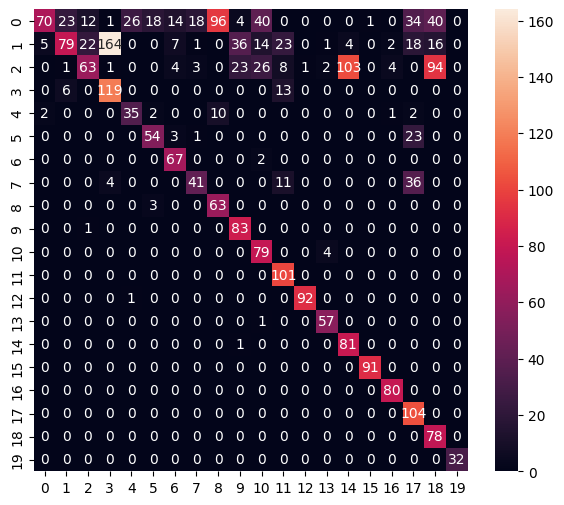

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.18      0.30       397
           1       0.72      0.20      0.32       392
           2       0.64      0.19      0.29       333
           3       0.41      0.86      0.56       138
           4       0.56      0.67      0.61        52
           5       0.70      0.67      0.68        81
           6       0.71      0.97      0.82        69
           7       0.64      0.45      0.53        92
           8       0.37      0.95      0.54        66
           9       0.56      0.99      0.72        84
          10       0.49      0.95      0.64        83
          11       0.65      1.00      0.79       101
          12       0.99      0.99      0.99        93
          13       0.89      0.98      0.93        58
          14       0.43      0.99      0.60        82
          15       0.99      1.00      0.99        91
          16       0.92      1.00      0.96        80
     

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [16]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [17]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\AVIANA~1\AppData\Local\Temp\tmpqzm9pk3k\assets


INFO:tensorflow:Assets written to: C:\Users\AVIANA~1\AppData\Local\Temp\tmpqzm9pk3k\assets


Saved artifact at 'C:\Users\AVIANA~1\AppData\Local\Temp\tmpqzm9pk3k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  2671416659600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2671416664016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2671416664208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2671416661328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2671416664592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2671416662288: TensorSpec(shape=(), dtype=tf.resource, name=None)


7260

# Inference test

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [19]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [21]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 1 ms


In [22]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[7.68519789e-02 1.24157099e-02 1.62921043e-03 2.36059446e-03
 2.90469468e-01 6.45355880e-02 5.32473065e-03 1.18008137e-01
 2.39204213e-01 1.17519726e-07 1.29053587e-05 1.78151438e-03
 1.05786763e-01 9.14629607e-04 1.30179416e-07 1.04171028e-02
 1.11816721e-02 5.82288466e-02 1.11939883e-15 8.76749575e-04]
4
